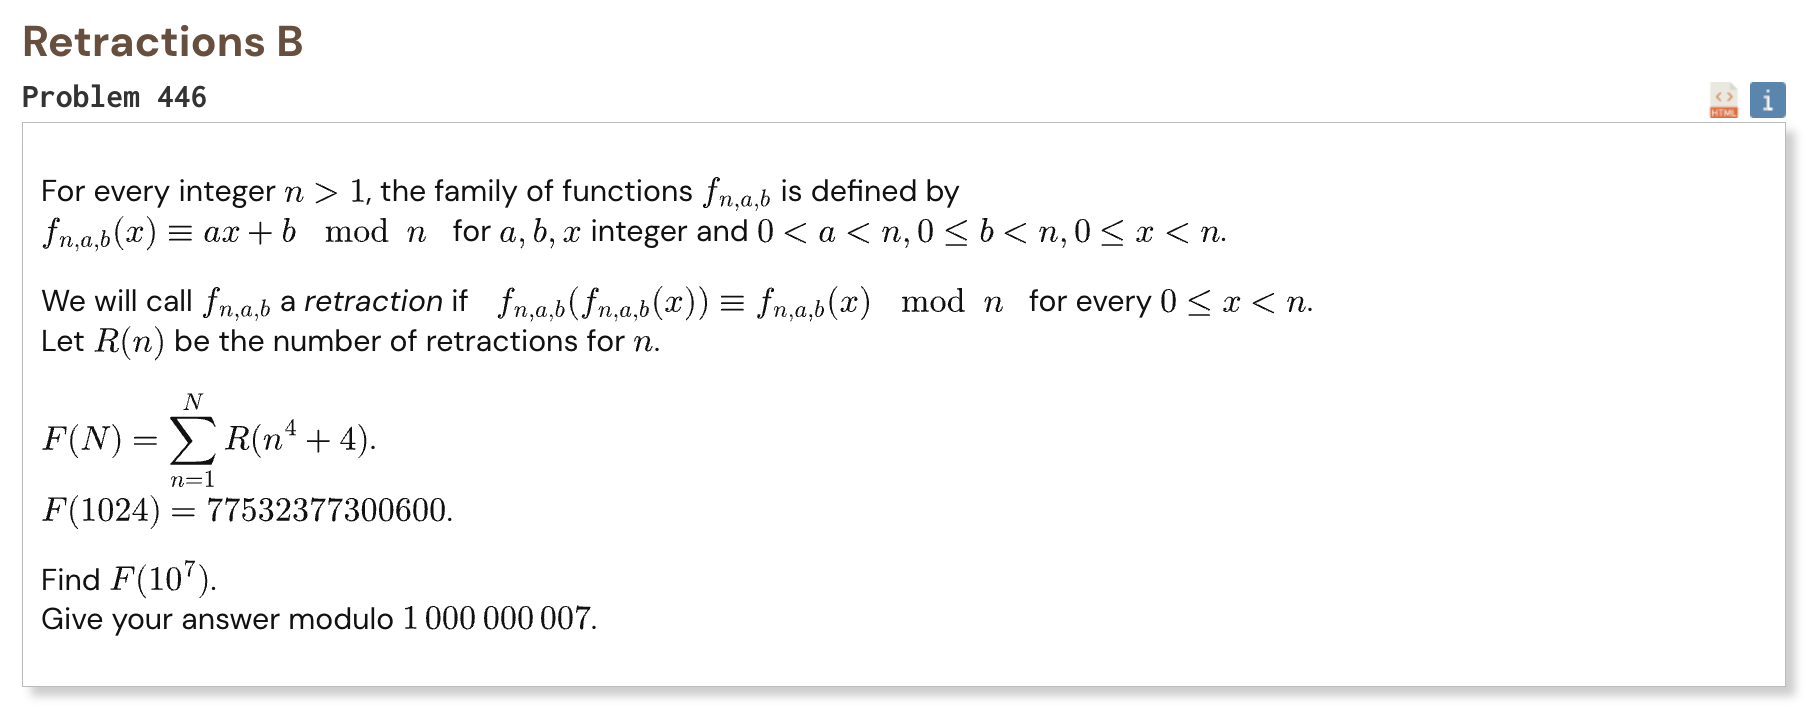

## Initial approach

-   rewrite the retraction count using the unitary divisors of each number
-   split the large expression into two much smaller factors that are easier to handle
-   precompute the needed divisor sums instead of factoring every large number separately
-   use a sieve over all values at once so each relevant prime is processed efficiently
-   only certain odd primes can divide the values produced by the smaller expressions
-   find where each such prime appears and remove all of its powers in one pass
-   use numpy to store the large arrays efficiently and numba to make the sieve loops fast
-   combine the two precomputed parts for every input value and add them to the final total

In [1]:
%%time

import numpy as np
from numba import njit

MOD = 1_000_000_007
N = 10_000_000

@njit
def mod_pow(a, e, mod):
    result = 1

    while e:
        if e & 1:
            result = result * a % mod
        a = a * a % mod
        e >>= 1

    return result

@njit
def sqrt_minus_one(p):
    z = 2

    while mod_pow(z, (p - 1) // 2, p) != p - 1:
        z += 1

    return mod_pow(z, (p - 1) // 4, p)

@njit
def prime_sieve(limit):
    is_prime = np.ones(limit + 1, dtype=np.uint8)
    is_prime[0] = 0
    is_prime[1] = 0

    p = 2

    while p * p <= limit:
        if is_prime[p]:
            for k in range(p * p, limit + 1, p):
                is_prime[k] = 0
        p += 1

    return is_prime

@njit
def solve(N):
    limit = N + 1

    remaining = np.empty(limit + 1, dtype=np.int64)
    sigma = np.ones(limit + 1, dtype=np.int64)

    for m in range(limit + 1):
        remaining[m] = m * m + 1

    for m in range(1, limit + 1, 2):
        remaining[m] //= 2
        sigma[m] = 3

    is_prime = prime_sieve(limit)

    for p in range(5, limit + 1, 4):
        if not is_prime[p]:
            continue

        r = sqrt_minus_one(p)

        for root in (r, p - r):
            for m in range(root, limit + 1, p):
                if remaining[m] % p != 0:
                    continue

                power = 1

                while remaining[m] % p == 0:
                    remaining[m] //= p
                    power *= p

                sigma[m] = sigma[m] * ((power + 1) % MOD) % MOD

    for m in range(limit + 1):
        if remaining[m] > 1:
            sigma[m] = sigma[m] * ((remaining[m] + 1) % MOD) % MOD

    inv9 = mod_pow(9, MOD - 2, MOD)
    even_factor = 5 * inv9 % MOD

    result = 0

    for n in range(1, N + 1):
        unitary_sum = sigma[n - 1] * sigma[n + 1] % MOD

        if n % 2 == 0:
            unitary_sum = unitary_sum * even_factor % MOD

        value = mod_pow(n, 4, MOD)
        value = (value + 4) % MOD

        result += unitary_sum - value
        result %= MOD

    return result

result = solve(N)

print("Result:", result)

Result: 907803852
CPU times: user 3.76 s, sys: 327 ms, total: 4.09 s
Wall time: 4.81 s
